In [1]:
#!pip install -r requirements.txt

In [2]:
import torch
from torch.utils.data import DataLoader
import optuna
import numpy as np
import pandas as pd
import feature_engineering
from dataset.dataset_construction import TimeSeriesDataset
from model import *

device = 'cuda' if torch.cuda.is_available() else 'cpu'

c:\Users\jvang\OneDrive\Desktop\UFRGS\6 Semestre\Ciência de Dados\guri-teimoso\Guri-Teimoso\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

In [4]:
file_path = './dataset/dataset.csv'
raw_dataset_df = pd.read_csv(file_path)

df_hybrid = feature_engineering.featureEng(raw_dataset_df)

X_train, y_train, X_test, y_test = feature_engineering.createSplit(df_hybrid)

preprocessor = feature_engineering.createPreprocessingPipeline(X_train.columns)
input_size = 28

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

def objective(trial):
    set_seed(42)

    hp = {
        'input_size':  input_size,
        'output_size': 1,
        'label_width': 1,
        'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
        'num_layers':  trial.suggest_int('num_layers', 1, 5),
        'dropout':     trial.suggest_float('dropout', 0.0, 0.4, step=0.1),
    }

    tp = {
        'batch_size': trial.suggest_categorical('batch_size', [32]),
        'lr':         trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'epochs':     20,
    }

    # Refit preprocessor cleanly for each trial
    trial_preprocessor = feature_engineering.createPreprocessingPipeline(X_train.columns)

    cv_history = crossValidate(
        X_train, y_train,
        hyperparameters=hp,
        preprocessor=trial_preprocessor,
        train_params=tp,
        n_splits=5,
        patience=5,
    )

    # Objective: average best MSE across folds
    mean_mse = np.mean([np.min(h['val_mae']) for h in cv_history])
    return mean_mse

In [6]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nBest MSE : {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 22. Best value: 2.11648: 100%|██████████| 40/40 [02:11<00:00,  3.29s/it]


Best MSE : 2.1165
Best params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.4, 'batch_size': 32, 'lr': 0.0017040047556276194}


In [5]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Drop the NaN rows created by lag shifts
X_train_processed = X_train_processed.dropna()
y_train = y_train.loc[X_train_processed.index]

X_test_processed = X_test_processed.dropna()
y_test = y_test.loc[X_test_processed.index]

train_df = pd.concat([X_train_processed, y_train], axis=1)
test_df  = pd.concat([X_test_processed,  y_test],  axis=1)

train_dataset = TimeSeriesDataset(train_df, input_width=7, label_width=1, shift=1, label_columns=['internacoes'])
test_dataset = TimeSeriesDataset(test_df, input_width=7, label_width=1, shift=1, label_columns=['internacoes'])

train_loader =  DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
hyperparameters = {
    'input_size': input_size,
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'label_width': 1,
    'dropout': 0.1
}

train_params = {
    'batch_size': 32,
    'lr': 1e-3,
    'epochs': 45
}

model = LSTMModel(
    input_size=hyperparameters['input_size'],
    hidden_size=hyperparameters['hidden_size'],
    num_layers=hyperparameters['num_layers'],
    output_size=hyperparameters['output_size'],
    label_width=hyperparameters['label_width'],
    dropout=hyperparameters['dropout']
)

model.to(device)

LSTMModel(
  (lstm): LSTM(28, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [7]:
model, history = train(model, train_loader, train_params)
result = evaluate(model, test_loader, device)
print(result)

{'loss': np.float64(5.017000079154968), 'mse': 5.190329074859619, 'mae': 1.861053705215454, 'rmse': np.float64(2.278229372749728), 'r2': 0.2634395360946655}


Analisando resultados

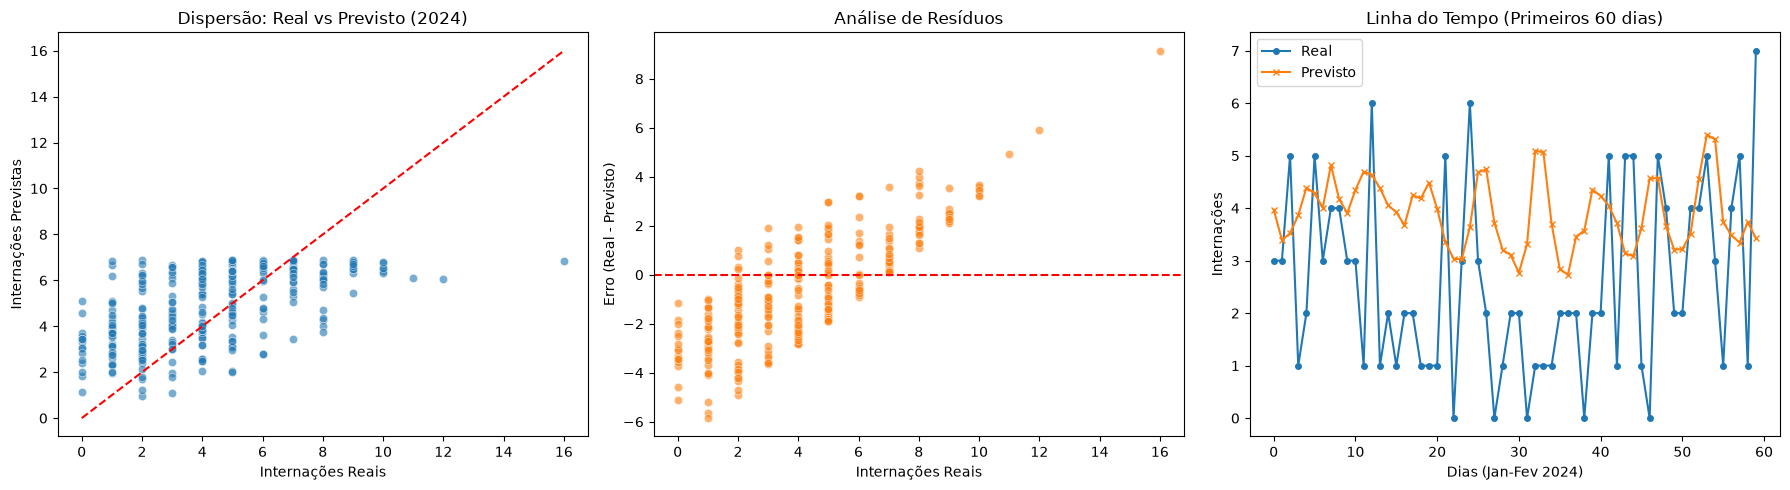

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extrair todas as previsões e valores reais do DataLoader de teste
model.eval()
previsoes_lstm = []
reais_lstm = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs)
        
        # Achata os tensores e move para a CPU
        previsoes_lstm.extend(preds.view(-1).cpu().numpy())
        reais_lstm.extend(labels.view(-1).cpu().numpy())

previsoes_lstm = np.array(previsoes_lstm)
reais_lstm = np.array(reais_lstm)
residuos = reais_lstm - previsoes_lstm

# 2. Configurar a figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Scatter Plot (Real vs Previsto) ---
sns.scatterplot(x=reais_lstm, y=previsoes_lstm, alpha=0.6, ax=axes[0], color='#1f77b4')
# Linha perfeita (onde y_real == y_previsto)
max_val = max(max(reais_lstm), max(previsoes_lstm))
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--')
axes[0].set_title('Dispersão: Real vs Previsto (2024)')
axes[0].set_xlabel('Internações Reais')
axes[0].set_ylabel('Internações Previstas')

# --- PLOT 2: Gráfico de Resíduos ---
sns.scatterplot(x=reais_lstm, y=residuos, alpha=0.6, ax=axes[1], color='#ff7f0e')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Análise de Resíduos')
axes[1].set_xlabel('Internações Reais')
axes[1].set_ylabel('Erro (Real - Previsto)')

# --- PLOT 3: Linha do Tempo (Amostra de 60 dias) ---
# Pegamos apenas os primeiros 60 dias para não poluir o gráfico
dias = 60
axes[2].plot(reais_lstm[:dias], label='Real', marker='o', markersize=4)
axes[2].plot(previsoes_lstm[:dias], label='Previsto', marker='x', markersize=4)
axes[2].set_title(f'Linha do Tempo (Primeiros {dias} dias)')
axes[2].set_xlabel('Dias (Jan-Fev 2024)')
axes[2].set_ylabel('Internações')
axes[2].legend()

plt.tight_layout()
plt.show()

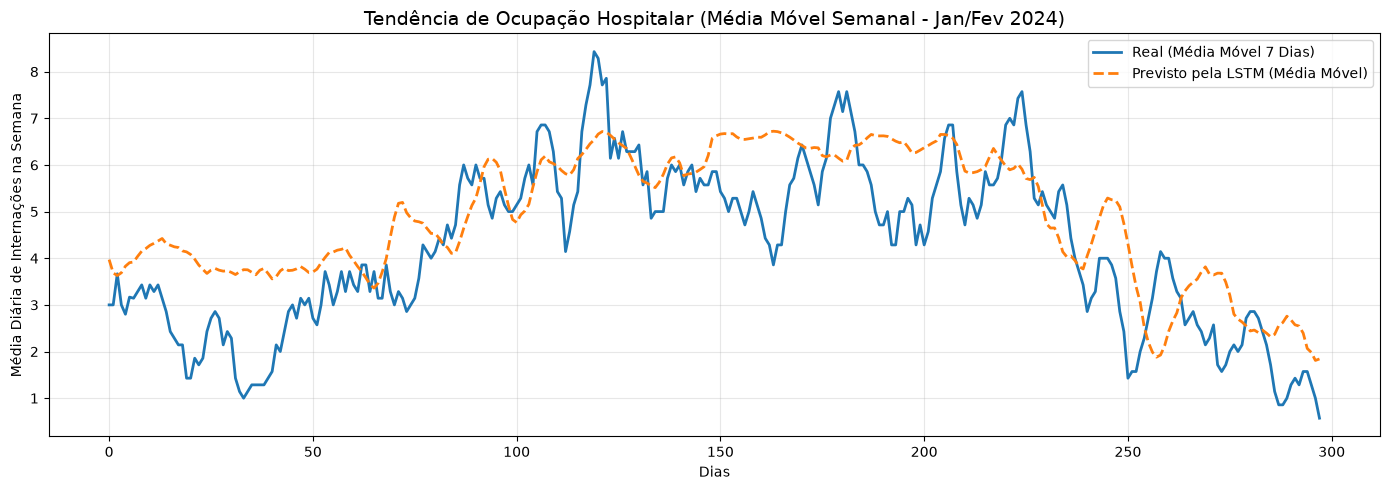

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Colocar os arrays em um DataFrame para facilitar o cálculo da janela
df_analise = pd.DataFrame({
    'Real': reais_lstm,
    'Previsto': previsoes_lstm
})

# 2. Calcular a Média Móvel de 7 dias
# Isso significa: "A ocupação média esperada para a próxima semana"
df_rolling = df_analise.rolling(window=7, min_periods=1).mean()

# 3. Plotar o resultado
plt.figure(figsize=(14, 5))
plt.plot(df_rolling['Real'], label='Real (Média Móvel 7 Dias)', linewidth=2, color='#1f77b4')
plt.plot(df_rolling['Previsto'], label='Previsto pela LSTM (Média Móvel)', linewidth=2, linestyle='--', color='#ff7f0e')

plt.title('Tendência de Ocupação Hospitalar (Média Móvel Semanal - Jan/Fev 2024)', fontsize=14)
plt.xlabel('Dias')
plt.ylabel('Média Diária de Internações na Semana')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SHAP VALUES

In [ ]:
import torch
import numpy as np
import shap

# ── 0. Derive true feature count from the processed DataFrame ─────────────────
# After the pipeline, X_train_processed has shape (n_rows, n_features)
# The TimeSeriesDataset windows it into (batch, input_width=7, n_features)
INPUT_WIDTH = 7
INPUT_SIZE  = X_train_processed.shape[1]   # true feature count, whatever it is
print(f"n_features after pipeline: {INPUT_SIZE}")   # confirm this equals 29

feature_names = X_train_processed.columns.tolist()  # save for plots later


# ── 1. Extract windowed numpy arrays directly from the DataLoader ─────────────
# This guarantees SHAP sees the exact same (batch, 7, n_features) tensors
# that the model was trained on — no manual windowing needed.

def extract_windows(loader, max_samples=None):
    """Pull (X, y) windows out of a DataLoader into numpy arrays."""
    xs = []
    for X_batch, _ in loader:
        xs.append(X_batch.numpy())
        if max_samples and sum(a.shape[0] for a in xs) >= max_samples:
            break
    X_np = np.concatenate(xs, axis=0)
    if max_samples:
        X_np = X_np[:max_samples]
    return X_np   # (n_samples, input_width, input_size)

X_train_windows = extract_windows(train_loader)
X_test_windows  = extract_windows(test_loader)

print("X_train_windows shape:", X_train_windows.shape)  # (n, 7, n_features)
print("X_test_windows shape :", X_test_windows.shape)   # (n, 7, n_features)


# ── 2. Wrapper: flattens model output to (batch,) ────────────────────────────
def model_predict(x_np: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        x_t = torch.tensor(x_np, dtype=torch.float32).to(next(model.parameters()).device)
        out = model(x_t)        # (batch, label_width=1, output_size=1)
        out = out[:, 0, 0]      # → (batch,)
    return out.cpu().numpy().astype(np.float64)


# ── 3. Background sample ──────────────────────────────────────────────────────
n_bg       = 50
bg_indices = np.random.choice(X_train_windows.shape[0], n_bg, replace=False)
background = X_train_windows[bg_indices]   # (50, 7, n_features)


# ── 4. Explainer ──────────────────────────────────────────────────────────────
bg_tensor  = torch.tensor(background, dtype=torch.float32).to(device)

class FlatModel(torch.nn.Module):
    def __init__(self, base): super().__init__(); self.base = base
    def forward(self, x): return self.base(x)[:, 0, 0].unsqueeze(1)  # (B, 1)

flat_model = FlatModel(model).train()

for module in flat_model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.eval()

explainer = shap.GradientExplainer(flat_model, bg_tensor)

X_explain = torch.tensor(X_test_windows[:100], dtype=torch.float32).to(device)

# ── Temporarily disable cuDNN so SHAP's internal .eval() call doesn't block backprop
torch.backends.cudnn.enabled = False
shap_values = explainer.shap_values(X_explain)
torch.backends.cudnn.enabled = True  # restore after

# ── 5. Shape normalisation ────────────────────────────────────────────────────
raw = np.array(shap_values)
print("raw shap_values shape:", raw.shape)
# GradientExplainer returns (n_samples, input_width, n_features, n_outputs)

if raw.ndim == 4 and raw.shape[-1] == 1:
    # Squeeze the trailing output dimension → (n_samples, input_width, n_features)
    shap_arr = raw[..., 0]
elif raw.ndim == 3:
    shap_arr = raw
else:
    raise ValueError(f"Unexpected shap_values shape: {raw.shape}")

print("shap_arr shape:", shap_arr.shape)        # expect (100, 7, 29)
n_samples, input_width, n_features = shap_arr.shape

# ── 6. Reconcile feature names ────────────────────────────────────────────────
print(f"feature_names: {len(feature_names)}  |  shap n_features: {n_features}")

if n_features == len(feature_names):
    feature_names_plot = feature_names
elif n_features == len(feature_names) + 1:
    print("WARNING: 'internacoes' is leaking into X — fix TimeSeriesDataset.")
    feature_names_plot = feature_names + ['internacoes']
else:
    raise ValueError(
        f"Cannot reconcile feature_names ({len(feature_names)}) "
        f"with shap_arr n_features ({n_features})"
    )

# ── 7. Aggregate ──────────────────────────────────────────────────────────────
shap_by_feature  = shap_arr.mean(axis=1)               # (100, 29) avg over timesteps
mean_abs_shap    = np.abs(shap_by_feature).mean(axis=0) # (29,)
mean_abs_by_step = np.abs(shap_arr).mean(axis=(0, 2))   # (7,)

ranked = sorted(zip(feature_names_plot, mean_abs_shap), key=lambda x: -x[1])
print("\nTop 10 features by mean |SHAP|:")
for name, val in ranked[:10]:
    print(f"  {name:35s}  {val:.6f}")

# ── 8. Plots ──────────────────────────────────────────────────────────────────
shap.summary_plot(
    shap_by_feature,
    feature_names=feature_names_plot,
    plot_type="bar",
    show=True
)

shap.summary_plot(
    shap_by_feature,
    feature_names=feature_names_plot,
    plot_type="dot",
    show=True
)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3))
plt.bar(range(input_width), mean_abs_by_step)
plt.xticks(range(input_width), [f"t-{input_width - i}" for i in range(input_width)])
plt.xlabel("Timestep (t-7 = oldest, t-1 = most recent)")
plt.ylabel("Mean |SHAP value|")
plt.title("Which day in the lookback window matters most?")
plt.tight_layout()
plt.show()

n_features after pipeline: 28
X_train_windows shape: (1203, 7, 28)
X_test_windows shape : (298, 7, 28)


RuntimeError: cudnn RNN backward can only be called in training mode